In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/janiobachmann/bank-marketing-dataset/bank.csv


# Libraries & Imports


In [2]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Machine Learning Models
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Model Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Display Settings
pd.set_option("display.max_columns", None)

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
df=pd.read_csv("/kaggle/input/datasets/janiobachmann/bank-marketing-dataset/bank.csv")
df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11157,33,blue-collar,single,primary,no,1,yes,no,cellular,20,apr,257,1,-1,0,unknown,no
11158,39,services,married,secondary,no,733,no,no,unknown,16,jun,83,4,-1,0,unknown,no
11159,32,technician,single,secondary,no,29,no,no,cellular,19,aug,156,2,-1,0,unknown,no
11160,43,technician,married,secondary,no,0,no,yes,cellular,8,may,9,2,172,5,failure,no


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


In [5]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,11162.0,NaN,NaN,NaN,41.231948,11.913369,18.0,32.0,39.0,49.0,95.0
job,11162,12,management,2566,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marital,11162,3,married,6351,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education,11162,4,secondary,5476,NaN,NaN,NaN,NaN,NaN,NaN,NaN
default,11162,2,no,10994,NaN,NaN,NaN,NaN,NaN,NaN,NaN
balance,11162.0,NaN,NaN,NaN,1528.538524,3225.413326,-6847.0,122.0,550.0,1708.0,81204.0
housing,11162,2,no,5881,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan,11162,2,no,9702,NaN,NaN,NaN,NaN,NaN,NaN,NaN
contact,11162,3,cellular,8042,NaN,NaN,NaN,NaN,NaN,NaN,NaN
day,11162.0,NaN,NaN,NaN,15.658036,8.42074,1.0,8.0,15.0,22.0,31.0


In [6]:
df.isna().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

# Target Distribution


deposit
no     5873
yes    5289
Name: count, dtype: int64

Percentage:
deposit
no     52.616019
yes    47.383981
Name: proportion, dtype: float64


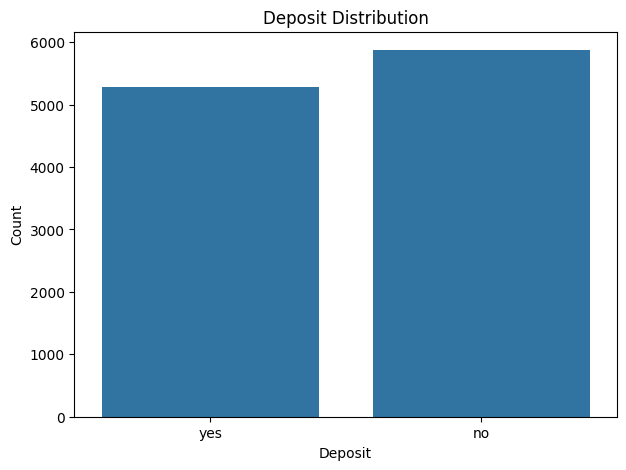

In [7]:
print(df["deposit"].value_counts())
print("\nPercentage:")
print(df["deposit"].value_counts(normalize=True) * 100)

plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="deposit")
plt.title("Deposit Distribution")
plt.xlabel("Deposit")
plt.ylabel("Count")
plt.show()

# Select numerical features


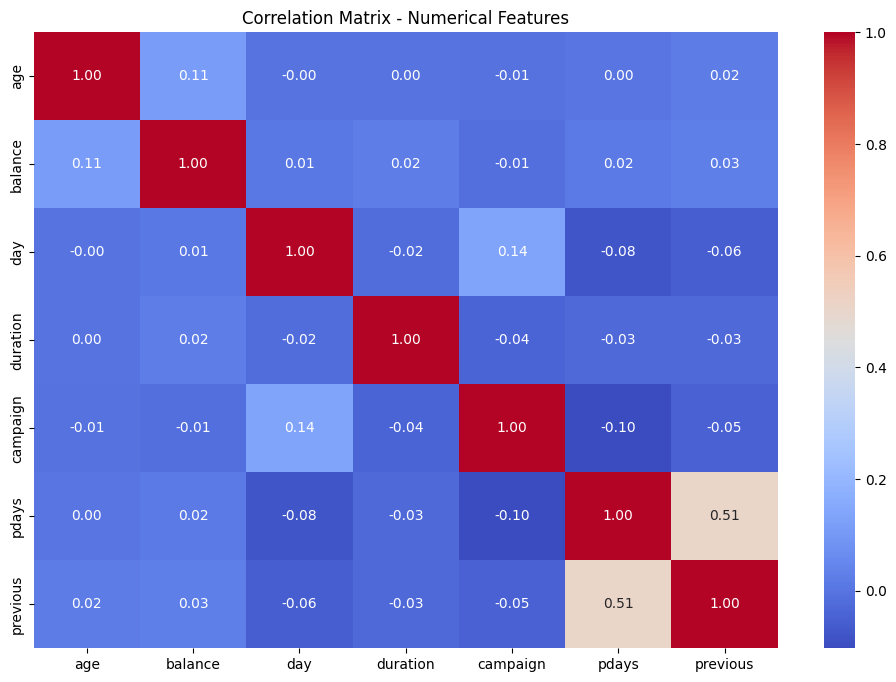

In [8]:
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns

# Correlation Matrix
plt.figure(figsize=(12, 8))
sns.heatmap(
    df[numerical_cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix - Numerical Features")
plt.show()

# Numerical Features Distribution


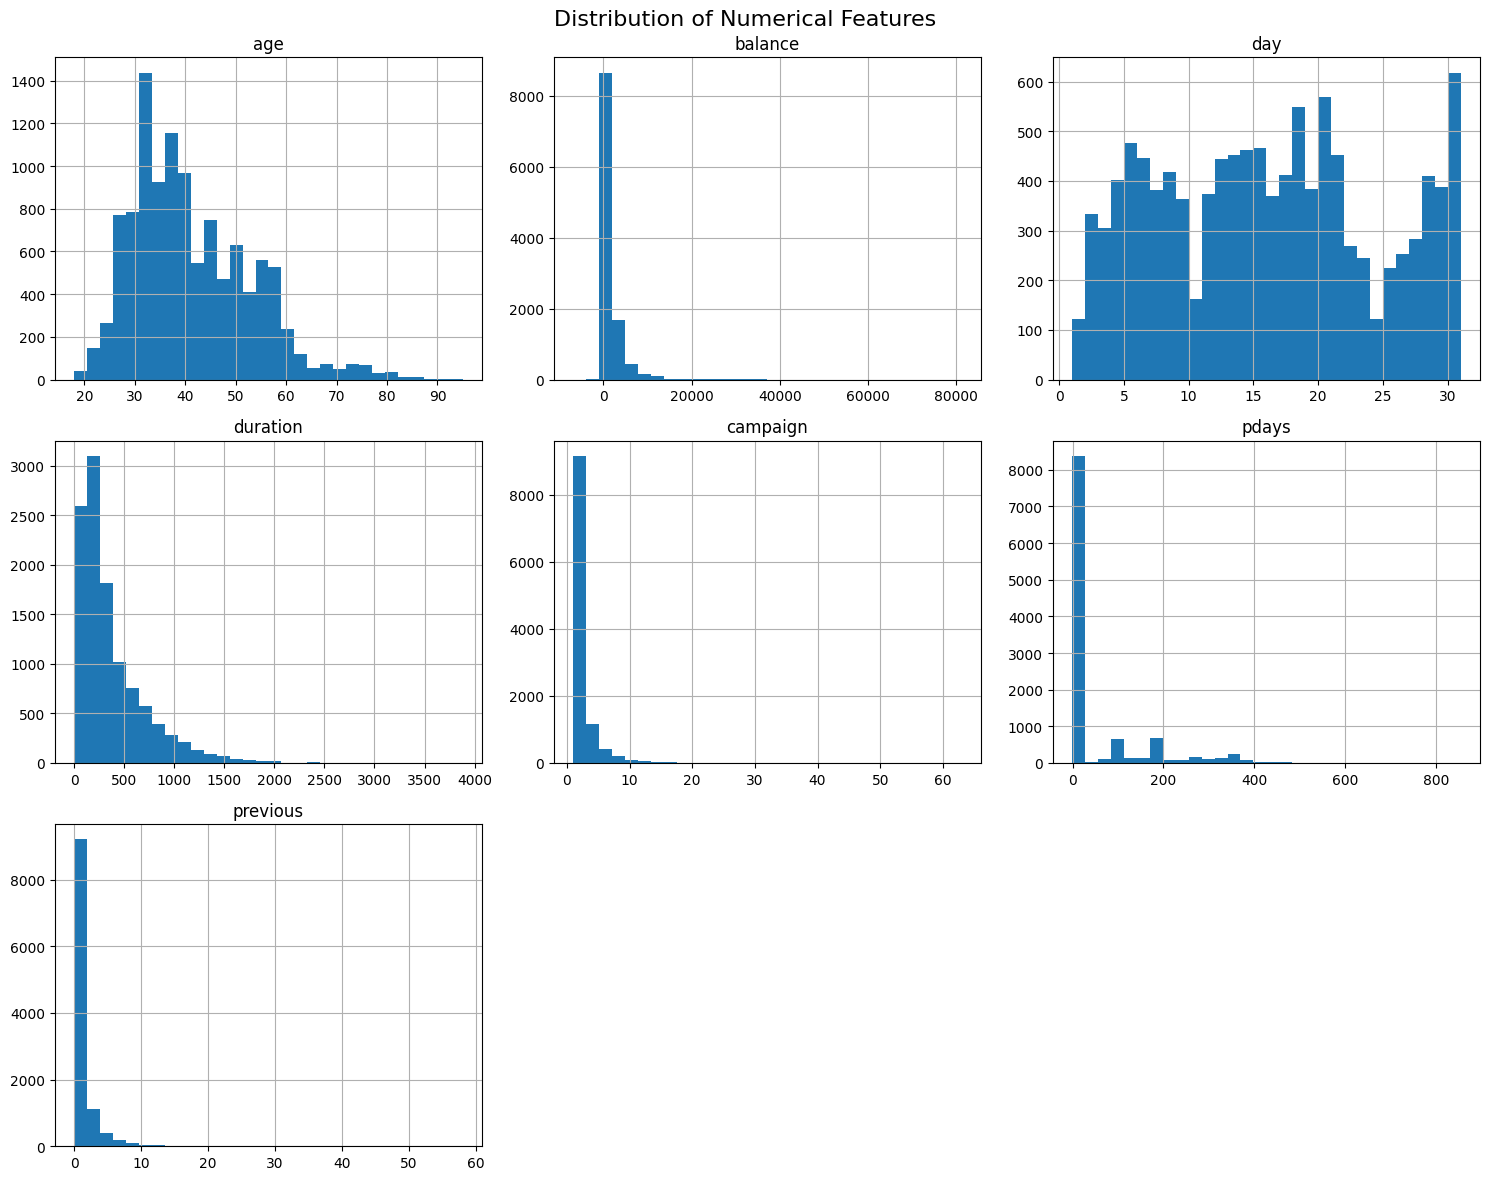

In [9]:

numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns

df[numerical_cols].hist(
    figsize=(15, 12),
    bins=30
)

plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

# Boxplots for Numerical Features


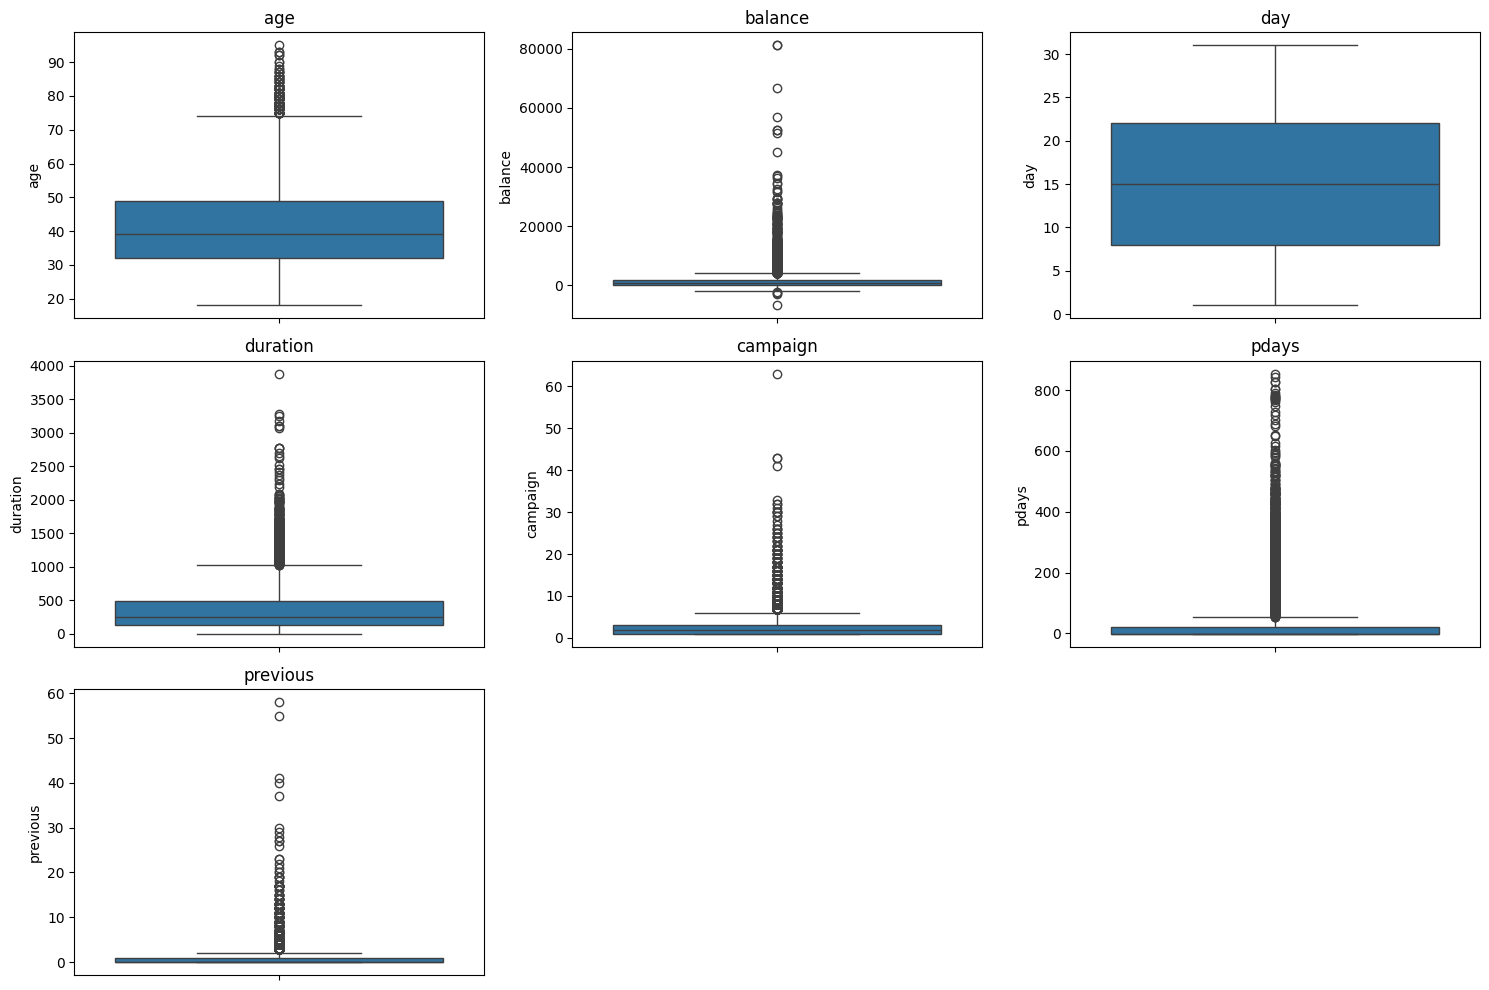

In [10]:

plt.figure(figsize=(15, 10))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

# Numerical Features vs Deposit


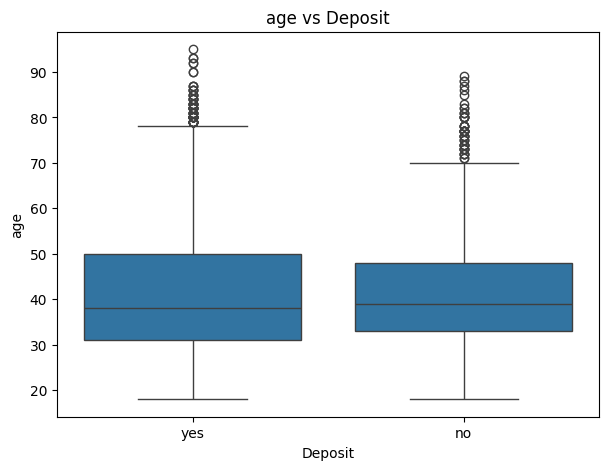

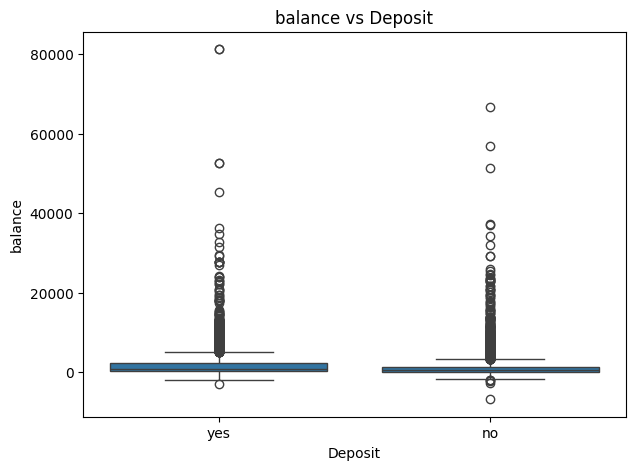

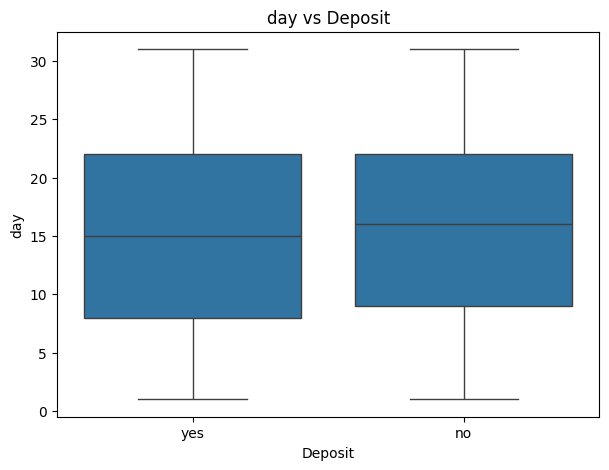

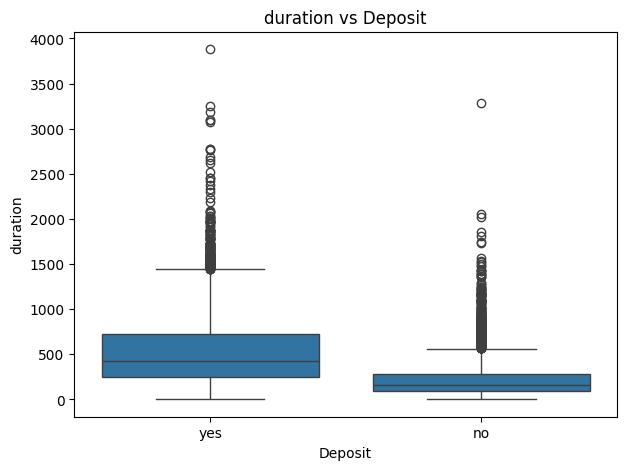

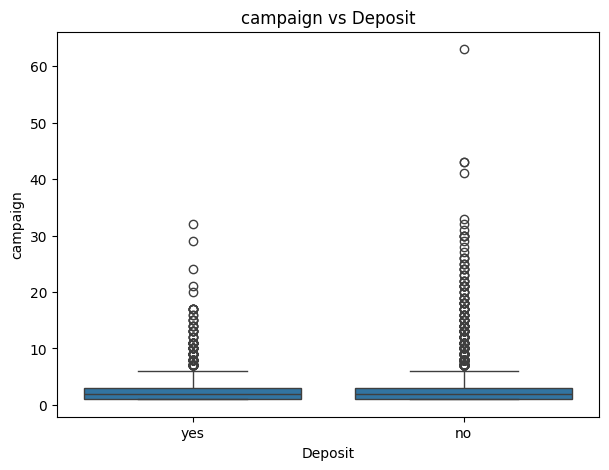

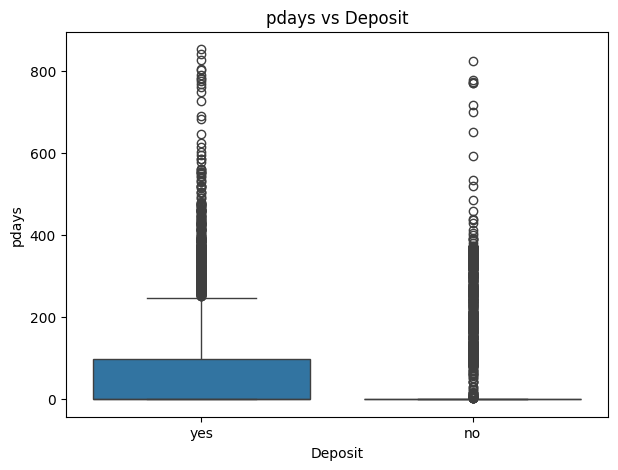

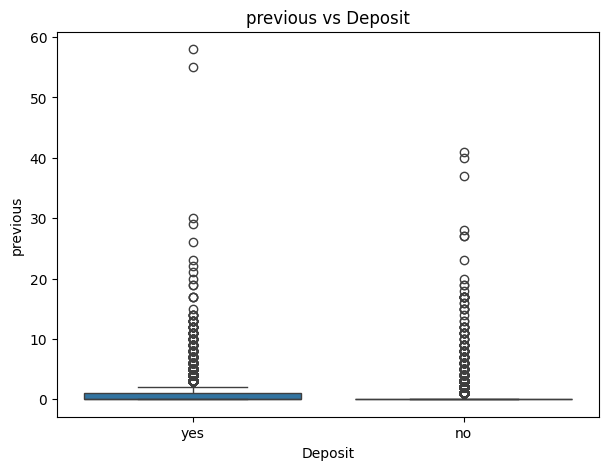

In [11]:

for col in numerical_cols:
    if col != "deposit":
        plt.figure(figsize=(7, 5))
        sns.boxplot(data=df, x="deposit", y=col)
        plt.title(f"{col} vs Deposit")
        plt.xlabel("Deposit")
        plt.ylabel(col)
        plt.show()

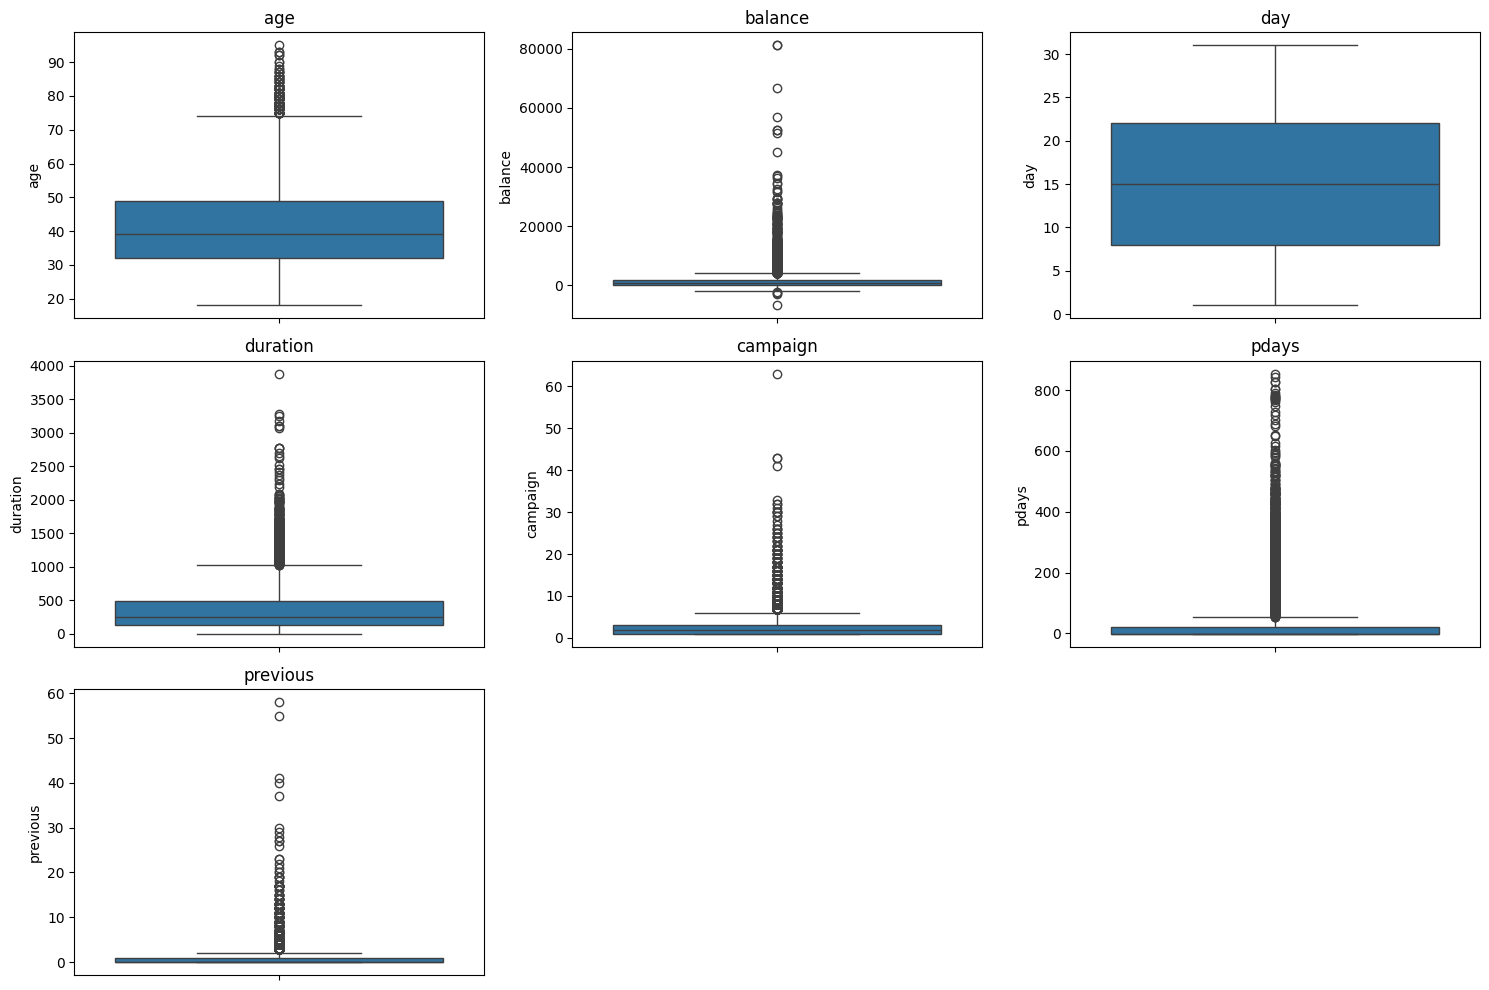

In [12]:
plt.figure(figsize=(15, 10))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

# Categorical Features


In [13]:
categorical_cols = df.select_dtypes(include=["object"]).columns.drop("deposit")

print("Categorical Features:")
print(categorical_cols.tolist())

Categorical Features:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


# Categorical Features vs Deposit


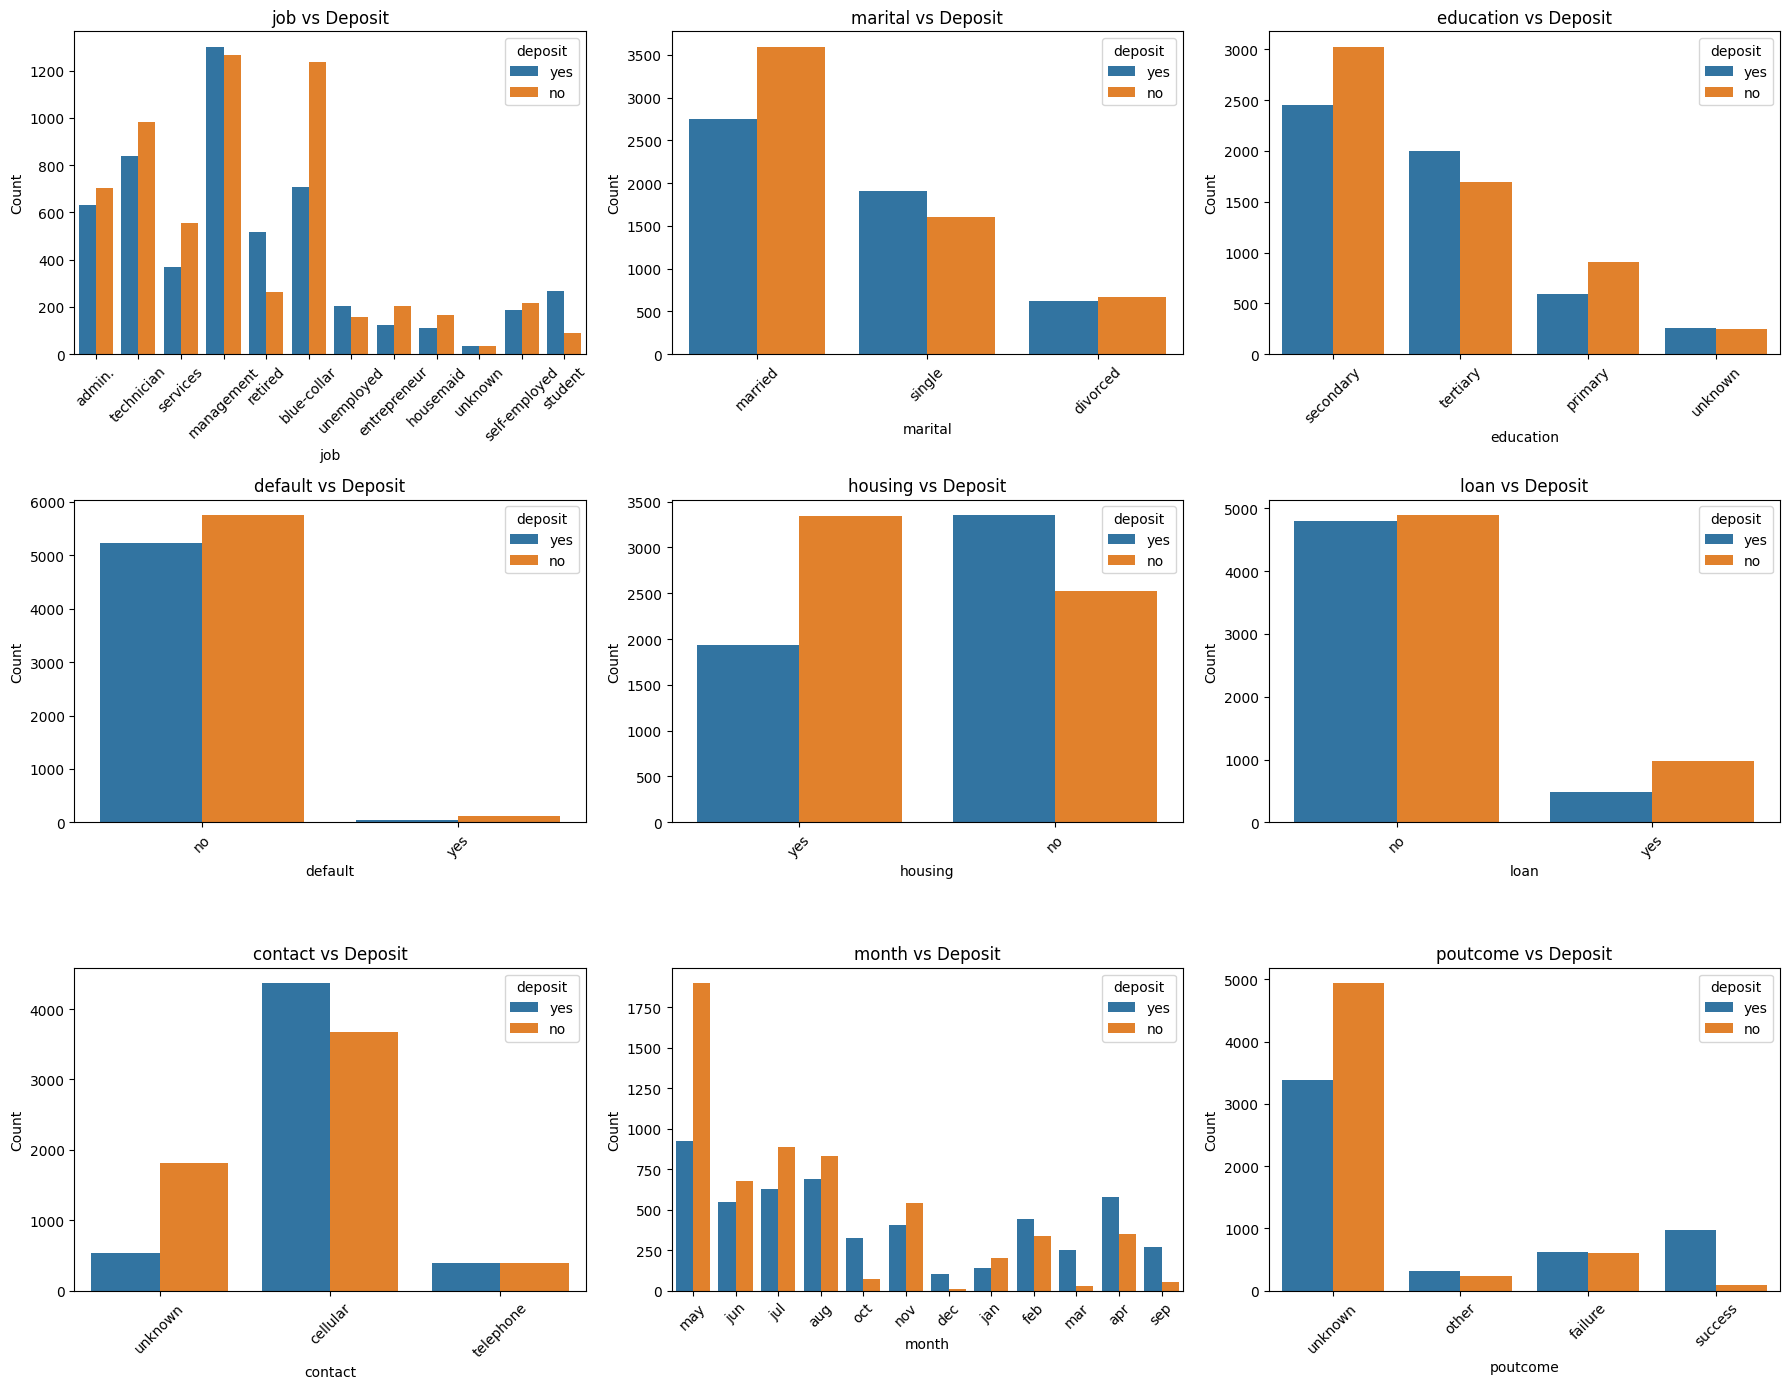

In [14]:
categorical_cols = df.select_dtypes(include=["object"]).columns.drop("deposit")

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    sns.countplot(data=df, x=col, hue="deposit", ax=axes[i])
    axes[i].set_title(f"{col} vs Deposit")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [15]:
categorical_cols = df.select_dtypes(include=["object"]).columns.drop("deposit")

for col in categorical_cols:
    
    deposit_rate = (
        df.groupby(col)["deposit"]
        .apply(lambda x: (x == "yes").mean() * 100)
        .sort_values(ascending=False)
    )
    
    print(f"\n{'='*50}")
    print(f"{col} - Deposit Yes Rate (%)")
    print(f"{'='*50}")
    print(deposit_rate.round(2))


job - Deposit Yes Rate (%)
job
student          74.72
retired          66.32
unemployed       56.58
management       50.70
unknown          48.57
admin.           47.30
self-employed    46.17
technician       46.08
services         39.98
housemaid        39.78
entrepreneur     37.50
blue-collar      36.42
Name: deposit, dtype: float64

marital - Deposit Yes Rate (%)
marital
single      54.35
divorced    48.11
married     43.38
Name: deposit, dtype: float64

education - Deposit Yes Rate (%)
education
tertiary     54.11
unknown      50.70
secondary    44.74
primary      39.40
Name: deposit, dtype: float64

default - Deposit Yes Rate (%)
default
no     47.64
yes    30.95
Name: deposit, dtype: float64

housing - Deposit Yes Rate (%)
housing
no     57.03
yes    36.64
Name: deposit, dtype: float64

loan - Deposit Yes Rate (%)
loan
no     49.53
yes    33.15
Name: deposit, dtype: float64

contact - Deposit Yes Rate (%)
contact
cellular     54.33
telephone    50.39
unknown      22.59
Name: dep

### Category Sample Size vs Deposit Rate

In [16]:

for col in categorical_cols:
    
    summary = (
        df.groupby(col)["deposit"]
        .agg(
            total_customers="count",
            yes_customers=lambda x: (x == "yes").sum(),
            deposit_yes_rate=lambda x: (x == "yes").mean() * 100
        )
        .sort_values("deposit_yes_rate", ascending=False)
    )
    
    summary["deposit_yes_rate"] = summary["deposit_yes_rate"].round(2)
    
    print(f"\n{'='*65}")
    print(f"{col} - Category Size and Deposit Rate")
    print(f"{'='*65}")
    print(summary)


job - Category Size and Deposit Rate
               total_customers  yes_customers  deposit_yes_rate
job                                                            
student                    360            269             74.72
retired                    778            516             66.32
unemployed                 357            202             56.58
management                2566           1301             50.70
unknown                     70             34             48.57
admin.                    1334            631             47.30
self-employed              405            187             46.17
technician                1823            840             46.08
services                   923            369             39.98
housemaid                  274            109             39.78
entrepreneur               328            123             37.50
blue-collar               1944            708             36.42

marital - Category Size and Deposit Rate
          total_customer

##  Previous Contact Indicator

In [17]:
previous_contact = (df["pdays"] != -1).astype(int)

previous_contact_analysis = (
    pd.DataFrame({
        "previous_contact": previous_contact,
        "deposit": df["deposit"]
    })
    .groupby("previous_contact")["deposit"]
    .agg(
        total_customers="count",
        yes_customers=lambda x: (x == "yes").sum(),
        deposit_yes_rate=lambda x: (x == "yes").mean() * 100
    )
)

previous_contact_analysis["deposit_yes_rate"] = (
    previous_contact_analysis["deposit_yes_rate"].round(2)
)

previous_contact_analysis

,total_customers,yes_customers,deposit_yes_rate
previous_contact,,,
0,8324,3384,40.65
1,2838,1905,67.12


In [18]:
df["previous_contact"] = (df["pdays"] != -1).astype(int)

# Check the new feature
df[["pdays", "previous_contact"]].head()

,pdays,previous_contact
0,-1,0
1,-1,0
2,-1,0
3,-1,0
4,-1,0


In [19]:
print("Dataset shape:", df.shape)

print("\nNew feature distribution:")
print(df["previous_contact"].value_counts())

print("\nMissing values:")
print(df["previous_contact"].isna().sum())

Dataset shape: (11162, 18)

New feature distribution:
previous_contact
0    8324
1    2838
Name: count, dtype: int64

Missing values:
0


In [20]:
X = df.drop("deposit", axis=1)
y = df["deposit"].map({"no": 0, "yes": 1})

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

print("\nTarget percentages:")
print((y.value_counts(normalize=True) * 100).round(2))

X shape: (11162, 17)
y shape: (11162,)

Target distribution:
deposit
0    5873
1    5289
Name: count, dtype: int64

Target percentages:
deposit
0    52.62
1    47.38
Name: proportion, dtype: float64


## Train-Test Split

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nTesting set:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

print("\nTraining target distribution:")
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nTesting target distribution:")
print((y_test.value_counts(normalize=True) * 100).round(2))

Training set:
X_train: (8929, 17)
y_train: (8929,)

Testing set:
X_test: (2233, 17)
y_test: (2233,)

Training target distribution:
deposit
0    52.62
1    47.38
Name: proportion, dtype: float64

Testing target distribution:
deposit
0    52.62
1    47.38
Name: proportion, dtype: float64


In [22]:
numerical_features = [
    "age", "balance", "day", "duration",
    "campaign", "pdays", "previous", "previous_contact"
]

categorical_features = [
    "job", "marital", "education", "default",
    "housing", "loan", "contact", "month", "poutcome"
]

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous', 'previous_contact']

Categorical features:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


## Encoding Categorical Features

In [23]:
X_train = pd.get_dummies(X_train, columns=categorical_features)
X_test = pd.get_dummies(X_test, columns=categorical_features)

In [24]:
X_train, X_test = X_train.align(
    X_test,
    join="left",
    axis=1,
    fill_value=0
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (8929, 52)
X_test shape: (2233, 52)


In [25]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled train shape:", X_train_scaled.shape)
print("Scaled test shape:", X_test_scaled.shape)

Scaled train shape: (8929, 52)
Scaled test shape: (2233, 52)


# DecisionTree

In [26]:
dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(X_train, y_train)

y_pred = dt_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.7917599641737573

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.82      0.80      1175
           1       0.79      0.76      0.78      1058

    accuracy                           0.79      2233
   macro avg       0.79      0.79      0.79      2233
weighted avg       0.79      0.79      0.79      2233



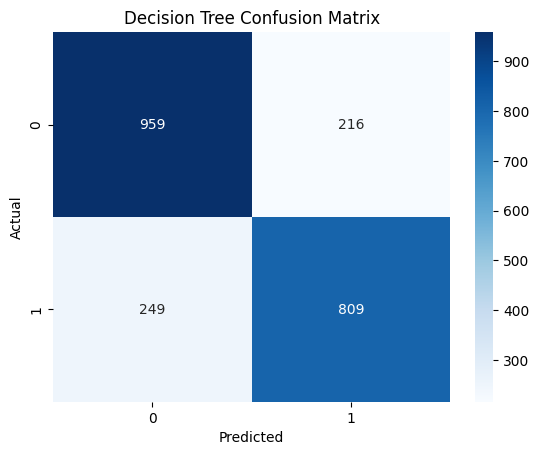

In [27]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Confusion Matrix")
plt.show()

# Logistic Regression 

In [28]:
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train_scaled, y_train)

lr_pred = lr_model.predict(X_test_scaled)

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, lr_pred))

print(classification_report(y_test, lr_pred))

Logistic Regression Accuracy: 0.8262427227944469
              precision    recall  f1-score   support

           0       0.82      0.85      0.84      1175
           1       0.83      0.80      0.81      1058

    accuracy                           0.83      2233
   macro avg       0.83      0.82      0.83      2233
weighted avg       0.83      0.83      0.83      2233



# KNeighborsClassifier

In [29]:
knn_model = KNeighborsClassifier(
    n_neighbors=5
)

knn_model.fit(X_train_scaled, y_train)

knn_pred = knn_model.predict(X_test_scaled)

print("KNN Accuracy:",
      accuracy_score(y_test, knn_pred))

print(classification_report(y_test, knn_pred))

KNN Accuracy: 0.7568293775190327
              precision    recall  f1-score   support

           0       0.74      0.82      0.78      1175
           1       0.77      0.69      0.73      1058

    accuracy                           0.76      2233
   macro avg       0.76      0.75      0.75      2233
weighted avg       0.76      0.76      0.76      2233



# Random Forest

In [30]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest Accuracy:",
      accuracy_score(y_test, rf_pred))

print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.8544558889386475
              precision    recall  f1-score   support

           0       0.88      0.83      0.86      1175
           1       0.82      0.88      0.85      1058

    accuracy                           0.85      2233
   macro avg       0.85      0.86      0.85      2233
weighted avg       0.86      0.85      0.85      2233



# SVM

In [31]:
svm_model = SVC(
    random_state=42
)

svm_model.fit(X_train_scaled, y_train)

svm_pred = svm_model.predict(X_test_scaled)

print("SVM Accuracy:",
      accuracy_score(y_test, svm_pred))

print(classification_report(y_test, svm_pred))

SVM Accuracy: 0.851321092700403
              precision    recall  f1-score   support

           0       0.87      0.85      0.86      1175
           1       0.83      0.86      0.85      1058

    accuracy                           0.85      2233
   macro avg       0.85      0.85      0.85      2233
weighted avg       0.85      0.85      0.85      2233



# XGBoost

In [32]:
xgb_model = XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

print("XGBoost Accuracy:",
      accuracy_score(y_test, xgb_pred))

print(classification_report(y_test, xgb_pred))

XGBoost Accuracy: 0.864755933721451
              precision    recall  f1-score   support

           0       0.89      0.85      0.87      1175
           1       0.84      0.89      0.86      1058

    accuracy                           0.86      2233
   macro avg       0.86      0.87      0.86      2233
weighted avg       0.87      0.86      0.86      2233



In [33]:
results = {
    "Decision Tree": accuracy_score(y_test, y_pred),
    "Logistic Regression": accuracy_score(y_test, lr_pred),
    "KNN": accuracy_score(y_test, knn_pred),
    "Random Forest": accuracy_score(y_test, rf_pred),
    "SVM": accuracy_score(y_test, svm_pred),
    "XGBoost": accuracy_score(y_test, xgb_pred)
}

results_df = pd.DataFrame(
    results.items(),
    columns=["Model", "Accuracy"]
)

results_df = results_df.sort_values(
    "Accuracy",
    ascending=False
)

results_df

,Model,Accuracy
5,XGBoost,0.864756
3,Random Forest,0.854456
4,SVM,0.851321
1,Logistic Regression,0.826243
0,Decision Tree,0.791760
2,KNN,0.756829


In [34]:
xgb_cv = cross_val_score(
    xgb_model,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

rf_cv = cross_val_score(
    rf_model,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

svm_cv = cross_val_score(
    svm_model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("XGBoost CV:", xgb_cv)
print("XGBoost Mean:", xgb_cv.mean())

print("\nRandom Forest CV:", rf_cv)
print("Random Forest Mean:", rf_cv.mean())

print("\nSVM CV:", svm_cv)
print("SVM Mean:", svm_cv.mean())

XGBoost CV: [0.86282195 0.85386338 0.85554311 0.85162374 0.85770308]
XGBoost Mean: 0.8563110529766217

Random Forest CV: [0.84770437 0.84714446 0.85442329 0.84322508 0.84369748]
Random Forest Mean: 0.8472389358879049

SVM CV: [0.85442329 0.83090705 0.84770437 0.83930571 0.832493  ]
SVM Mean: 0.8409666845461589


Final Model: XGBoost
Accuracy: 0.864755933721451

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.85      0.87      1175
           1       0.84      0.89      0.86      1058

    accuracy                           0.86      2233
   macro avg       0.86      0.87      0.86      2233
weighted avg       0.87      0.86      0.86      2233



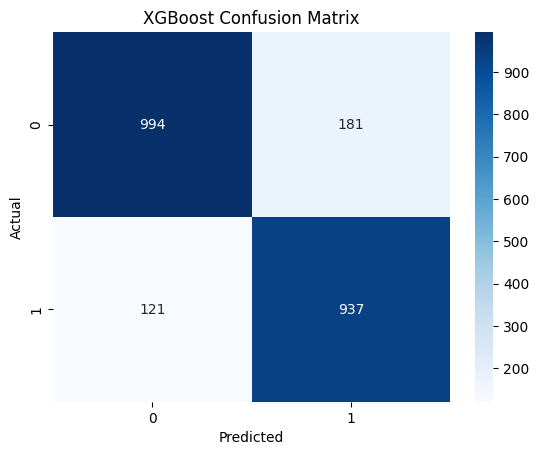

In [35]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Final predictions
y_pred = xgb_model.predict(X_test)

# Accuracy
print("Final Model: XGBoost")
print("Accuracy:", accuracy_score(y_test, y_pred))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost Confusion Matrix")

plt.show()

In [36]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
50,poutcome_success,0.141384
35,contact_unknown,0.104043
43,month_mar,0.074040
29,housing_no,0.046997
3,duration,0.044344
46,month_oct,0.034876
42,month_jun,0.031262
47,month_sep,0.030784
45,month_nov,0.028094
6,previous,0.026332


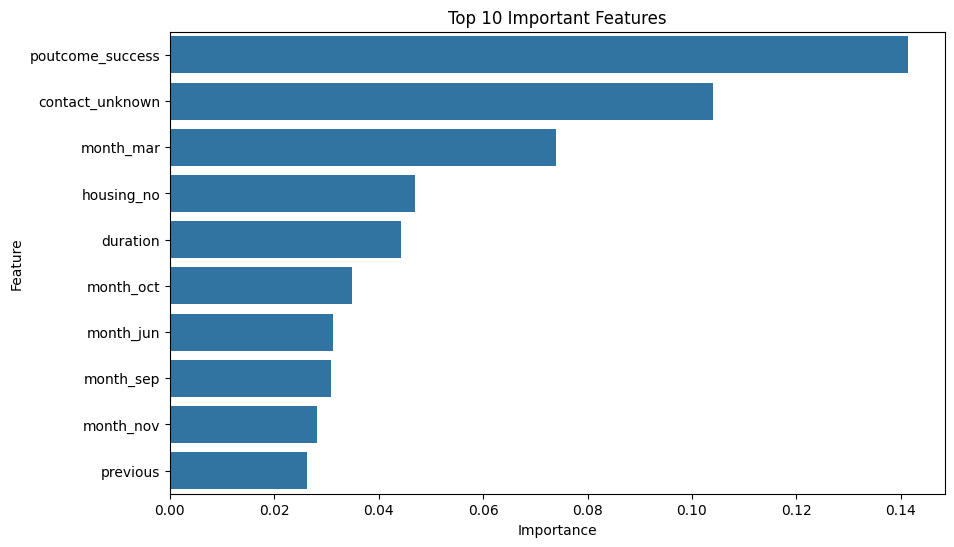

In [37]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")
plt.show()

# Final Insights

- Customers who had been contacted previously had a much higher deposit subscription rate (**67.12%**) compared with customers who had not been contacted before (**40.65%**).

- The previous campaign outcome was one of the strongest indicators. Customers with a **successful previous campaign** had a **91.32%** subscription rate, compared with **40.67%** for customers with an unknown previous outcome.

- Customers **without a housing loan** showed a higher subscription rate (**57.03%**) compared with customers with a housing loan (**36.64%**).

- Subscription rates varied significantly across months. **March, September, October, and December** showed the highest rates, while **May** showed the lowest rate (**32.75%**).

- Subscription behavior also varied by customer characteristics. **Students (74.72%)** and **retired customers (66.32%)** had among the highest subscription rates, while **blue-collar workers (36.42%)** had a lower rate.

## Model Performance

Six machine learning models were evaluated. **XGBoost achieved the best baseline performance with an accuracy of 86.48%**, followed by Random Forest (85.45%) and SVM (85.13%).

## Conclusion

The analysis shows that previous customer interactions, campaign outcomes, contact method, customer characteristics, and campaign timing are important factors associated with deposit subscription.

Among the evaluated models, **XGBoost was the best-performing model**, achieving **86.48% accuracy** on the test set.